In [1]:
from sklearn.datasets import fetch_openml
# load dataset
mnist_data = fetch_openml('mnist_784', version=1, as_frame=False)

print(mnist_data.data.shape, mnist_data.target.shape)

(70000, 784) (70000,)


In [2]:
# splitting the loaded data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(mnist_data.data, mnist_data.target, test_size=0.2, random_state=42)

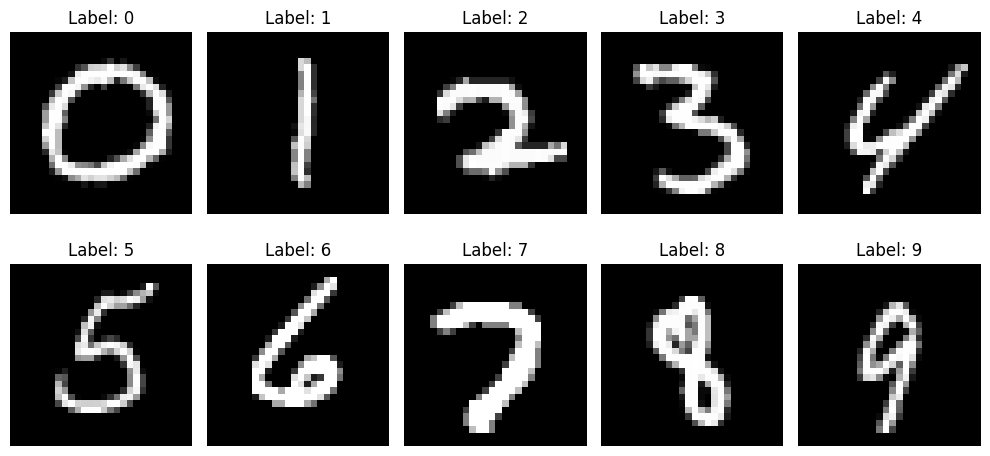

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for digit in range(10):
    idx = np.where(y_train == str(digit))[0][0]
    image = X_train[idx].reshape(28, 28)

    ax = axes[digit // 5, digit % 5]
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {digit}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# normalize the pixel values (makes convergence faster)

X_train, X_test = X_train / 255.0, X_test / 255.0

In [4]:
%load_ext cuml.accel

In [6]:
from sklearn.linear_model import LogisticRegression

# create a logistic regression model

reg = LogisticRegression(max_iter=1000, random_state=42, solver='saga', l1_ratio=0.5, penalty='elasticnet')
reg.fit(X_train, y_train)


[2026-07-08 12:25:56.429] [CUML] [warning] QWL-QN: max iterations reached
[2026-07-08 12:25:56.429] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


LogisticRegression(l1_ratio=0.5, max_iter=1000, penalty='elasticnet',
                   random_state=42, solver='saga')

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# make predictions on the training and test sets
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

def performace_metrics(y_test, y_pred):
  # calculate and print training accuracy
  train_accuracy = accuracy_score(y_train, y_train_pred)
  print(f"Training Accuracy: {train_accuracy:.4f}")

  # calculate and print test accuracy
  test_accuracy = accuracy_score(y_test, y_test_pred)
  print(f"Test Accuracy: {test_accuracy:.4f}")
  # Generate and print the classification report for the test set
  class_report = classification_report(y_test, y_test_pred)
  print("Classification Report for Test Set:")
  print(class_report)

In [12]:
performace_metrics(y_test, y_test_pred)

Training Accuracy: 0.9386
Test Accuracy: 0.9220
Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1343
           1       0.95      0.97      0.96      1600
           2       0.91      0.90      0.91      1380
           3       0.91      0.90      0.90      1433
           4       0.92      0.93      0.92      1295
           5       0.88      0.88      0.88      1273
           6       0.95      0.95      0.95      1396
           7       0.93      0.94      0.94      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



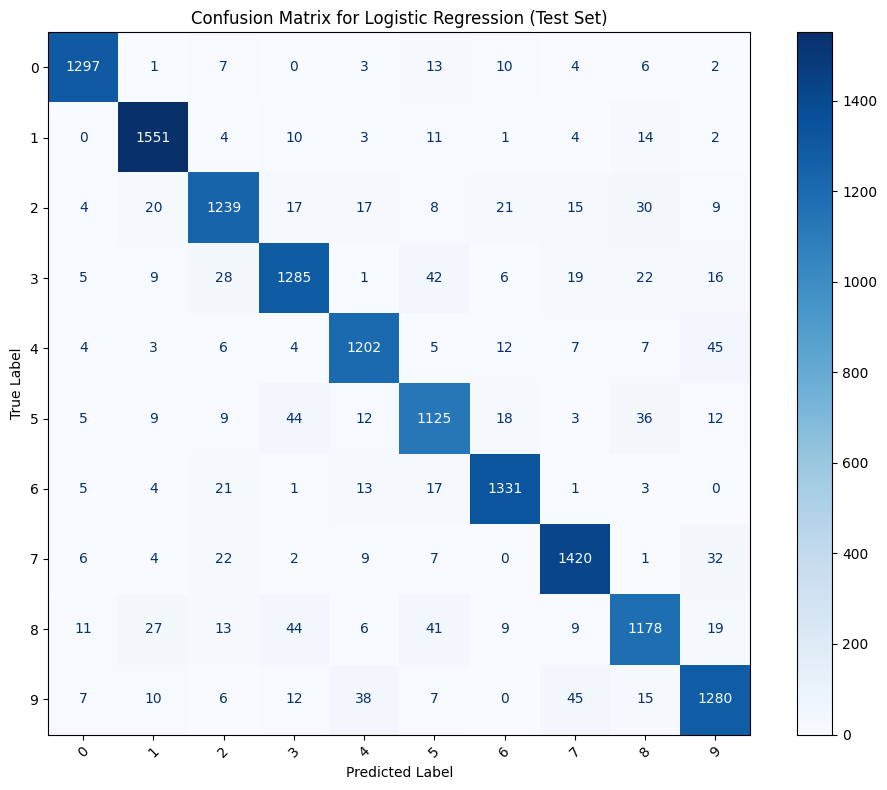

In [9]:
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=reg.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Logistic Regression (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Observation


- The Logistic Regression model achieved an **overall accuracy of 92%**, showing strong performance on the MNIST dataset.
- The confusion matrix has a **strong diagonal**, indicating that most digits were classified correctly.
- Digits **0, 1, 6 and 7** were recognized with the highest accuracy due to their distinct shapes.
- Digits **5** and **8** had the lowest performance because they often resemble other handwritten digits.
- Common misclassifications include **3 <--> 5**, **4 <--> 9**, and **5 <--> 8**, as these digits have similar handwritten patterns.
- The **Elastic Net regularization** helped reduce overfitting while maintaining good generalization.
- Despite being a **linear classifier**, Logistic Regression provides an excellent baseline for handwritten digit recognition.